# Phase 3c — AST Fine-Tuning (Focal Loss + Supervised Contrastive Learning)
**Project:** Robust Respiratory Sound Classification under Noise and Domain Shift using Audio Spectrogram Transformers

**Goal this notebook:** add a Supervised Contrastive (SupCon) head alongside the classifier, following the combined-loss formula from the proposal: `L_total = L_Focal + λ · L_SupCon`. Reference implementation approach: Kim et al. (2023), "Stethoscope-guided Supervised Contrastive Learning".

**Supervised Contrastive Learning:** it adds a second training signal that pulls same-class cycles' embeddings closer together and pushes different-class embeddings apart, *in addition to* the classification objective. Two independently-augmented "views" of each cycle are created (via SpecAugment masking), and any other same-label example in the batch -- from either view -- counts as a positive pair.

**Required inputs for this notebook (Add Input on Kaggle):**
1. **`03-ast-finetuning-ce`** -- for its cached raw waveforms (`waveform_cache/`)
2. **`01-data-preparation`** -- for `splits/train.csv`, `val.csv`, `test.csv`



In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt
import librosa

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler


from transformers import ASTFeatureExtractor, ASTForAudioClassification, get_linear_schedule_with_warmup

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.dpi"] = 110

## **1. Config**



In [ ]:
# =========================
# Reproducibility
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# =========================
# Paths
# =========================
PHASE1_DIR = Path(
    "/kaggle/input/notebooks/praveshsubba/01-data-preparation/icbhi_processed"
)
SPLIT_DIR = PHASE1_DIR / "splits"

CE_NOTEBOOK_DIR = Path(
    "/kaggle/input/notebooks/praveshsubba/03a-ast-finetuning-ce"
)
WAVEFORM_CACHE_DIR = CE_NOTEBOOK_DIR / "waveform_cache"

CHECKPOINT_DIR = Path("/kaggle/working/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = Path("/kaggle/working/results_phase3c.csv")


# =========================
# Labels
# =========================
LABELS = ["normal", "crackle", "wheeze", "both"]


# =========================
# Audio preprocessing constants 
# =========================
TARGET_SR = 16000
LOWCUT = 50
HIGHCUT = 8000
TARGET_DURATION = 8.0


# =========================
# AST model config
# =========================
AST_CHECKPOINT = "MIT/ast-finetuned-audioset-10-10-0.4593"
# Dimension of the contrastive projection embedding.
# The projection head is used during training, not for classification inference.
PROJECTION_DIM = 128


# =========================
# Training config
# =========================
BATCH_SIZE = 4          # halved vs. the Focal notebook -- each step sees 2x this
                         # many forward passes (both views), same GPU memory envelope
NUM_WORKERS = 2
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
MAX_EPOCHS = 15
EARLY_STOP_PATIENCE = 4
GRAD_CLIP_NORM = 1.0

# Focal Loss 
FOCAL_GAMMA = 2.0

# SupCon-specific
SUPCON_TEMPERATURE = 0.07 
LAMBDA_SUPCON = 0.5   

# SpecAugment (used here specifically to generate the two contrastive views --
# NOT the same as the standalone augmentation ablation study in 03d)
TIME_MASK_PARAM = 100
FREQ_MASK_PARAM = 20
N_TIME_MASKS = 2
N_FREQ_MASKS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
assert DEVICE.type == "cuda" # "Enable the GPU accelerator for this notebook before continuing.

Device: cuda


## **2. Load splits + resolve cached waveforms**

In [3]:
train_df = pd.read_csv(SPLIT_DIR / "train.csv")
val_df   = pd.read_csv(SPLIT_DIR / "val.csv")
test_df  = pd.read_csv(SPLIT_DIR / "test.csv")

required_cols = {"audio_path", "start", "end", "label"}
missing = required_cols - set(train_df.columns)
assert not missing, f"Missing expected columns: {missing}"

print(train_df.shape, val_df.shape, test_df.shape)


(4580, 14) (1133, 14) (1185, 14)


In [4]:
from pathlib import Path

def resolve_waveform_path(row, cache_dir=WAVEFORM_CACHE_DIR):
    # Recreate the exact filename used during Phase 1
    cycle_id = f"{Path(row['audio_path']).stem}_{float(row['start'])}_{float(row['end'])}"
    
    waveform_path = cache_dir / f"{cycle_id}.npy"

    # look for the existing waveform.
    # do NOT regenerate it.
    if not waveform_path.exists():
        raise FileNotFoundError(
            f"Waveform not found:\n{waveform_path}"
        )

    return str(waveform_path)


# Create waveform_path column for all splits
for name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df)
]:
    df["waveform_path"] = [
        resolve_waveform_path(row)
        for _, row in df.iterrows()
    ]

    print(f"{name}: {len(df)} waveform paths created")

print("\nAll waveform paths resolved successfully.")

train: 4580 waveform paths created
val: 1133 waveform paths created
test: 1185 waveform paths created

All waveform paths resolved successfully.


In [5]:
train_df.head() # check

,cycle_id,patient_id,recording_id,chest_location,acquisition_mode,equipment,audio_path,start,end,crackle,wheeze,label,duration,spectrogram_path,waveform_path
0,101_1b1_Al_sc_Meditron_0,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,0.036,0.579,0,0,normal,0.543,/kaggle/working/icbhi_processed/spectrograms/1...,/kaggle/input/notebooks/praveshsubba/03a-ast-f...
1,101_1b1_Al_sc_Meditron_1,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,0.579,2.450,0,0,normal,1.871,/kaggle/working/icbhi_processed/spectrograms/1...,/kaggle/input/notebooks/praveshsubba/03a-ast-f...
2,101_1b1_Al_sc_Meditron_2,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,2.450,3.893,0,0,normal,1.443,/kaggle/working/icbhi_processed/spectrograms/1...,/kaggle/input/notebooks/praveshsubba/03a-ast-f...
3,101_1b1_Al_sc_Meditron_3,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,3.893,5.793,0,0,normal,1.900,/kaggle/working/icbhi_processed/spectrograms/1...,/kaggle/input/notebooks/praveshsubba/03a-ast-f...
4,101_1b1_Al_sc_Meditron_4,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,5.793,7.521,0,0,normal,1.728,/kaggle/working/icbhi_processed/spectrograms/1...,/kaggle/input/notebooks/praveshsubba/03a-ast-f...


## **3. SpecAugment for Contrastive Views**

SpecAugment applies time and frequency masking to the AST feature representation. During training, two independently augmented views are created from the same respiratory cycle.

The views share the original class label and provide paired examples for supervised contrastive learning. Validation and test data use unaugmented inputs.

This two-view mechanism is specific to the contrastive-learning experiment; it is distinct from the standalone augmentation ablation in Phase 3D.


In [6]:
def spec_augment(x, time_mask_param=TIME_MASK_PARAM, freq_mask_param=FREQ_MASK_PARAM,n_time_masks=N_TIME_MASKS, n_freq_masks=N_FREQ_MASKS):
    x = x.clone()
    T, M = x.shape   # (1024, 128)
    fill_value = x.mean()

    for _ in range(n_time_masks):
        t = np.random.randint(0, time_mask_param)
        t0 = np.random.randint(0, max(T - t, 1))
        x[t0:t0 + t, :] = fill_value

    for _ in range(n_freq_masks):
        f = np.random.randint(0, freq_mask_param)
        f0 = np.random.randint(0, max(M - f, 1))
        x[:, f0:f0 + f] = fill_value

    return x

## **4. AST Feature Extraction and Two-View Dataset**

The dataset loads each cached waveform and applies the pretrained AST feature extractor.

For training, each example returns two independently masked feature representations and one shared class label. Validation and test examples are unaugmented; the duplicated view is retained only to keep the DataLoader output structure consistent.

The DataLoaders batch these examples for model training and evaluation.


In [ ]:
feature_extractor = ASTFeatureExtractor.from_pretrained(AST_CHECKPOINT)

class ASTSupConDataset(Dataset):
    def __init__(self, df, feature_extractor, label_list=LABELS, augment=True):
        self.df = df.reset_index(drop=True)
        self.fe = feature_extractor
        self.label2idx = {l: i for i, l in enumerate(label_list)}
        self.augment = augment   # Disable augmentation for validation and test.

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        waveform = np.load(row["waveform_path"])
        features = self.fe(waveform, sampling_rate=TARGET_SR, return_tensors="pt")
        base = features["input_values"].squeeze(0)   # (1024, 128)

        y = torch.tensor(self.label2idx[row["label"]], dtype=torch.long)

        if self.augment:
            view1 = spec_augment(base)
            view2 = spec_augment(base)
            return view1, view2, y
        else:
            return base, base, y   # val/test: both "views" identical, unused for SupCon


train_ds = ASTSupConDataset(train_df, feature_extractor, augment=True)
val_ds   = ASTSupConDataset(val_df,   feature_extractor, augment=False)
test_ds  = ASTSupConDataset(test_df,  feature_extractor, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

v1, v2, yb = next(iter(train_loader))
print("View shapes:", v1.shape, v2.shape, "| labels:", yb.shape)

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

View shapes: torch.Size([4, 1024, 128]) torch.Size([4, 1024, 128]) | labels: torch.Size([4])


## **5. Model with a parallel projection head**

The pretrained backbone and original classifier head are reused exactly as in the CE/Focal notebooks -- a small 2-layer MLP projection head is added *alongside* the classifier, taking the same pooled representation as input. The projection head is only used during training (for `L_SupCon`); at inference, only the classifier head's output matters, and the projection head is simply not called.

In [ ]:
id2label = {i: l for i, l in enumerate(LABELS)}
label2id = {l: i for i, l in enumerate(LABELS)}

base_model = ASTForAudioClassification.from_pretrained(
    AST_CHECKPOINT,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(DEVICE)

hidden_size = base_model.config.hidden_size   # 768

projection_head = nn.Sequential(  # Projection head for SupCon embeddings
    nn.Linear(hidden_size, hidden_size),
    nn.ReLU(inplace=True),
    nn.Linear(hidden_size, PROJECTION_DIM),
).to(DEVICE)


def forward_with_projection(input_values):
    """Runs the AST backbone once, returns both the classification logits
    (from the original pretrained classifier head) and the L2-normalized
    projection embedding (from the new SupCon head) -- reusing the same
    pooled representation for both, rather than running the backbone twice.
    """
    backbone_out = base_model.audio_spectrogram_transformer(input_values=input_values)
    pooled = backbone_out.pooler_output          # (B, hidden_size)
    logits = base_model.classifier(pooled)       # (B, n_classes)
    proj = F.normalize(projection_head(pooled), dim=1)   
    return logits, proj


n_params = sum(p.numel() for p in base_model.parameters()) + sum(p.numel() for p in projection_head.parameters())
print(f"Total parameters (backbone + classifier + projection head): {n_params:,}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Total parameters (backbone + classifier + projection head): 86,880,900


## **6. Focal Loss and Supervised Contrastive Loss**

**Focal loss** provides the classification objective, with class weights and a focusing parameter of \(\gamma=2.0\).

**Supervised contrastive loss** operates on L2-normalized projection embeddings. Embeddings with the same class label form positive pairs, excluding each embedding's comparison with itself. Embeddings with different labels contribute negative comparisons.

The total training loss is:

$$
L_{\mathrm{total}} =
L_{\mathrm{focal}} + \lambda L_{\mathrm{SupCon}}
$$

The experiment uses \(\lambda=0.5\) and a contrastive temperature of \(0.07\).


In [9]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction="none")
        p_t = torch.exp(-ce_loss)
        focal_term = (1 - p_t) ** self.gamma
        loss = focal_term * ce_loss
        if self.alpha is not None:
            loss = self.alpha[targets] * loss
        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss


class SupConLoss(nn.Module):
    """Khosla et al. (2020), multi-positive supervised contrastive loss.
    `features` must already be L2-normalized. `labels` gives the class of
    each row in `features` -- any other row sharing the same label counts
    as a positive for that anchor.
    """
    def __init__(self, temperature=SUPCON_TEMPERATURE):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        device = features.device
        N = features.shape[0]

        similarity = torch.matmul(features, features.T) / self.temperature
        sim_max, _ = torch.max(similarity, dim=1, keepdim=True)
        similarity = similarity - sim_max.detach()   # numerical stability

        labels = labels.contiguous().view(-1, 1)
        pos_mask = torch.eq(labels, labels.T).float().to(device)

        logits_mask = torch.ones((N, N), device=device) - torch.eye(N, device=device)
        pos_mask = pos_mask * logits_mask

        exp_sim = torch.exp(similarity) * logits_mask
        log_prob = similarity - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)

        num_pos = torch.clamp(pos_mask.sum(dim=1), min=1)
        mean_log_prob_pos = (pos_mask * log_prob).sum(dim=1) / num_pos

        return -mean_log_prob_pos.mean()


class_counts = train_df["label"].value_counts().reindex(LABELS).fillna(0)
class_weights = (1.0 / class_counts).values
class_weights = class_weights / class_weights.sum() * len(LABELS)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

focal_criterion = FocalLoss(alpha=class_weights, gamma=FOCAL_GAMMA)
supcon_criterion = SupConLoss(temperature=SUPCON_TEMPERATURE)

optimizer = torch.optim.AdamW(
    list(base_model.parameters()) + list(projection_head.parameters()),
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)
total_steps = len(train_loader) * MAX_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
scaler = GradScaler("cuda")

## **7. Evaluation Metric — ICBHI Score**

The ICBHI score groups crackle, wheeze and both into the abnormal category and evaluates normal-versus-abnormal sensitivity and specificity.

The score is their arithmetic mean. Four-class classification reports and confusion matrices are also retained to show performance for each respiratory sound class.


In [10]:
def icbhi_score(y_true_labels, y_pred_labels):
    y_true_abn = np.array([l != "normal" for l in y_true_labels])
    y_pred_abn = np.array([l != "normal" for l in y_pred_labels])
    normal_mask = ~y_true_abn
    specificity = (~y_pred_abn[normal_mask]).sum() / normal_mask.sum()
    abnormal_mask = y_true_abn
    sensitivity = y_pred_abn[abnormal_mask].sum() / abnormal_mask.sum()
    score = (sensitivity + specificity) / 2
    return {"sensitivity": sensitivity, "specificity": specificity, "icbhi_score": score}


idx2label = {i: l for i, l in enumerate(LABELS)}

def evaluate_and_report(y_true, y_pred, model_name):
    scores = icbhi_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"Sensitivity: {scores['sensitivity']*100:.2f}%")
    print(f"Specificity: {scores['specificity']*100:.2f}%")
    print(f"ICBHI Score:  {scores['icbhi_score']*100:.2f}%\n")
    print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABELS)
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{model_name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()
    return scores


results_log = []

def log_result(model_name, split, scores, notes=""):
    results_log.append({
        "model": model_name, "split": split,
        "sensitivity": scores["sensitivity"], "specificity": scores["specificity"],
        "icbhi_score": scores["icbhi_score"], "notes": notes,
    })
    pd.DataFrame(results_log).to_csv(RESULTS_CSV, index=False)

## **8. Training Loop**

Each training step concatenates the two augmented views into a single batch, runs the AST backbone once, and computes both classification logits and contrastive embeddings.

The focal-loss term is computed over the combined batch. The supervised contrastive term uses the normalized embeddings and their labels. The weighted contrastive contribution is then added to the focal-loss term.

Validation uses the classification head only, without augmentation or the contrastive objective. The best checkpoint is selected by validation ICBHI score, with early stopping when the score stops improving.


In [11]:
def train_epoch(loader, lambda_supcon):
    base_model.train()
    projection_head.train()
    total_loss = 0.0
    n_samples = 0

    for view1, view2, yb in loader:
        view1, view2, yb = view1.to(DEVICE), view2.to(DEVICE), yb.to(DEVICE) # move to gpu
        x_combined = torch.cat([view1, view2], dim=0)          # (2B, 1024, 128)
        y_combined = torch.cat([yb, yb], dim=0)                # (2B,) -- same label, both views

        optimizer.zero_grad()

        with autocast("cuda"):
            logits, proj = forward_with_projection(x_combined)
            loss_focal = focal_criterion(logits, y_combined)
            loss_supcon = supcon_criterion(proj, y_combined)
            loss = loss_focal + lambda_supcon * loss_supcon

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            list(base_model.parameters()) + list(projection_head.parameters()), GRAD_CLIP_NORM
        )
        scale_before = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        if scaler.get_scale() >= scale_before:
            scheduler.step()

        total_loss += loss.item() * x_combined.size(0)
        n_samples += x_combined.size(0)

    return total_loss / n_samples


def eval_epoch(loader):
    """Classifier-only evaluation -- no SupCon, no augmentation, single view."""
    base_model.eval()
    projection_head.eval()
    all_true, all_pred = [], []

    with torch.no_grad():
        for view1, _view2, yb in loader:   # view1 == view2 for val/test (augment=False)
            view1 = view1.to(DEVICE)
            with autocast("cuda"):
                logits, _ = forward_with_projection(view1)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_true.extend(idx2label[i] for i in yb.numpy())
            all_pred.extend(idx2label[i] for i in preds)

    return icbhi_score(all_true, all_pred), all_true, all_pred


def run_training(lambda_supcon, run_name, max_epochs=MAX_EPOCHS, patience=EARLY_STOP_PATIENCE):
    history = {"train_loss": [], "val_icbhi_score": []}
    best_val_score = -1
    epochs_without_improvement = 0
    checkpoint_path = CHECKPOINT_DIR / f"{run_name}_best.pt"

    for epoch in range(1, max_epochs + 1):
        train_loss = train_epoch(train_loader, lambda_supcon)
        val_scores, _, _ = eval_epoch(val_loader)

        history["train_loss"].append(train_loss)
        history["val_icbhi_score"].append(val_scores["icbhi_score"])

        print(f"[{run_name}] Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
              f"val_ICBHI_score={val_scores['icbhi_score']*100:.2f}%")

        if val_scores["icbhi_score"] > best_val_score:
            best_val_score = val_scores["icbhi_score"]
            epochs_without_improvement = 0
            torch.save({
                "base_model": base_model.state_dict(),
                "projection_head": projection_head.state_dict(),
            }, checkpoint_path)
            print(f"  -> new best (saved to {checkpoint_path.name})")
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    return history, best_val_score, checkpoint_path

## **9. Run training (default: single λ = 0.5)**

[ast_supcon_lambda0.5] Epoch 01 | train_loss=1.2232 | val_ICBHI_score=67.18%
  -> new best (saved to ast_supcon_lambda0.5_best.pt)
[ast_supcon_lambda0.5] Epoch 02 | train_loss=1.0483 | val_ICBHI_score=65.71%
[ast_supcon_lambda0.5] Epoch 03 | train_loss=0.9657 | val_ICBHI_score=69.15%
  -> new best (saved to ast_supcon_lambda0.5_best.pt)
[ast_supcon_lambda0.5] Epoch 04 | train_loss=0.8774 | val_ICBHI_score=68.94%
[ast_supcon_lambda0.5] Epoch 05 | train_loss=0.8127 | val_ICBHI_score=68.03%
[ast_supcon_lambda0.5] Epoch 06 | train_loss=0.7544 | val_ICBHI_score=68.80%
[ast_supcon_lambda0.5] Epoch 07 | train_loss=0.7182 | val_ICBHI_score=66.86%
Early stopping at epoch 7


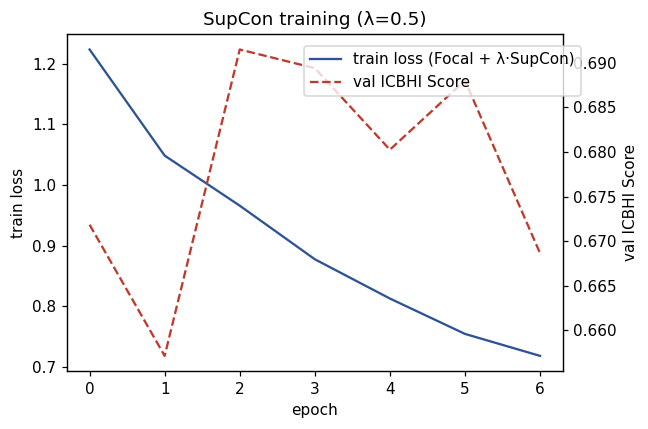

In [12]:
history, best_val_score, best_checkpoint_path = run_training(
    lambda_supcon=LAMBDA_SUPCON, run_name=f"ast_supcon_lambda{LAMBDA_SUPCON}"
)

fig, ax = plt.subplots(figsize=(6, 4))
ax2 = ax.twinx()
ax.plot(history["train_loss"], color="#2E5395", label="train loss (Focal + λ·SupCon)")
ax2.plot(history["val_icbhi_score"], color="#C0392B", linestyle="--", label="val ICBHI Score")
ax.set_xlabel("epoch"); ax.set_ylabel("train loss"); ax2.set_ylabel("val ICBHI Score")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.title(f"SupCon training (λ={LAMBDA_SUPCON})")
plt.tight_layout()
plt.show()

## **10. Evaluate best checkpoint (val), then test set once**

--- AST + Focal + SupCon (λ=0.5, val) ---
Sensitivity: 66.81%
Specificity: 71.49%
ICBHI Score:  69.15%

              precision    recall  f1-score   support

      normal       0.75      0.71      0.73       663
     crackle       0.52      0.61      0.56       347
      wheeze       0.53      0.38      0.44        66
        both       0.36      0.30      0.33        57

    accuracy                           0.64      1133
   macro avg       0.54      0.50      0.52      1133
weighted avg       0.65      0.64      0.64      1133



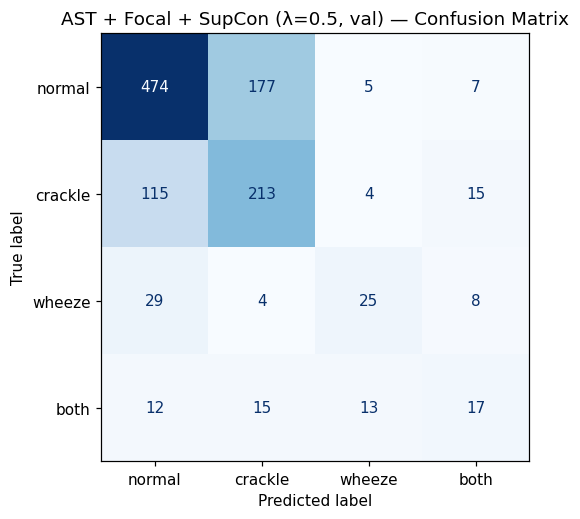

In [13]:
checkpoint = torch.load(best_checkpoint_path)
base_model.load_state_dict(checkpoint["base_model"])
projection_head.load_state_dict(checkpoint["projection_head"])

val_scores, val_true, val_pred = eval_epoch(val_loader)
evaluate_and_report(val_true, val_pred, f"AST + Focal + SupCon (λ={LAMBDA_SUPCON}, val)")
log_result("AST + Focal + SupCon", "val", val_scores, notes=f"lambda_supcon={LAMBDA_SUPCON}")

--- AST + Focal + SupCon (λ=0.5, TEST) ---
Sensitivity: 43.49%
Specificity: 88.86%
ICBHI Score:  66.17%

              precision    recall  f1-score   support

      normal       0.70      0.89      0.78       709
     crackle       0.50      0.19      0.27       298
      wheeze       0.43      0.34      0.38       104
        both       0.35      0.43      0.39        74

    accuracy                           0.64      1185
   macro avg       0.49      0.46      0.46      1185
weighted avg       0.60      0.64      0.59      1185



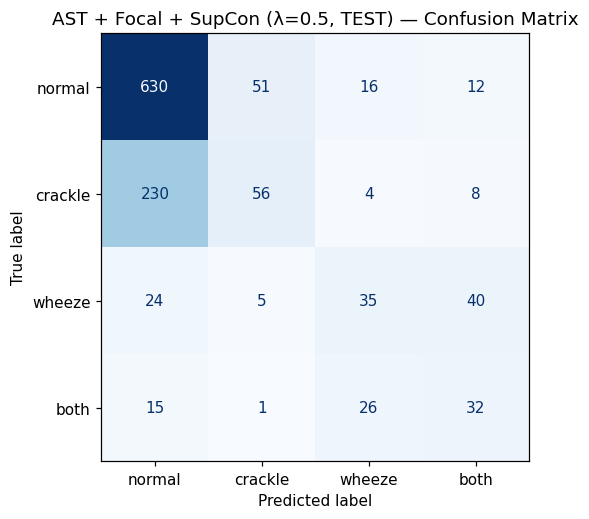

In [14]:
# --- TEST set ---
test_scores, test_true, test_pred = eval_epoch(test_loader)
evaluate_and_report(test_true, test_pred, f"AST + Focal + SupCon (λ={LAMBDA_SUPCON}, TEST)")
log_result("AST + Focal + SupCon", "test", test_scores, notes=f"lambda_supcon={LAMBDA_SUPCON}")

## 11. Optional — λ sweep

**Only run this if you have GPU-hour budget for it** -- each value below is a full training run from a freshly-reloaded pretrained model, not a cheap tweak. Uncomment to use. This is the concrete "tune λ" step from the proposal, and its output is real ablation-table content either way (even "λ=1.0 was worse" is a reportable finding, not a failed experiment).

In [15]:
# LAMBDA_GRID = [0.1, 1.0]   # 0.5 already run above
#
# for lam in LAMBDA_GRID:
#     # reload a fresh pretrained model + projection head for a fair comparison --
#     # reusing the already-fine-tuned weights from the λ=0.5 run would contaminate this run
#     base_model = ASTForAudioClassification.from_pretrained(
#         AST_CHECKPOINT, num_labels=len(LABELS), id2label=id2label, label2id=label2id,
#         ignore_mismatched_sizes=True,
#     ).to(DEVICE)
#     projection_head = nn.Sequential(
#         nn.Linear(hidden_size, hidden_size), nn.ReLU(inplace=True),
#         nn.Linear(hidden_size, PROJECTION_DIM),
#     ).to(DEVICE)
#     optimizer = torch.optim.AdamW(
#         list(base_model.parameters()) + list(projection_head.parameters()),
#         lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
#     )
#     scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
#     scaler = torch.amp.GradScaler("cuda")
#
#     _, _, ckpt_path = run_training(lambda_supcon=lam, run_name=f"ast_supcon_lambda{lam}")
#     checkpoint = torch.load(ckpt_path)
#     base_model.load_state_dict(checkpoint["base_model"])
#     projection_head.load_state_dict(checkpoint["projection_head"])
#
#     test_scores, test_true, test_pred = eval_epoch(test_loader)
#     evaluate_and_report(test_true, test_pred, f"AST + Focal + SupCon (λ={lam}, TEST)")
#     log_result("AST + Focal + SupCon", "test", test_scores, notes=f"lambda_supcon={lam}")

## **12. Results table**

In [16]:
results_df = pd.DataFrame(results_log)
results_df["sensitivity"] = (results_df["sensitivity"] * 100).round(2)
results_df["specificity"] = (results_df["specificity"] * 100).round(2)
results_df["icbhi_score"] = (results_df["icbhi_score"] * 100).round(2)

display_cols = ["model", "split", "sensitivity", "specificity", "icbhi_score", "notes"]
results_df[display_cols].to_csv(RESULTS_CSV, index=False)
results_df[display_cols]

,model,split,sensitivity,specificity,icbhi_score,notes
0,AST + Focal + SupCon,val,66.81,71.49,69.15,lambda_supcon=0.5
1,AST + Focal + SupCon,test,43.49,88.86,66.17,lambda_supcon=0.5


## **13. Phase 3C Summary — Focal Loss and Supervised Contrastive Learning**

This experiment combines class-weighted focal loss with supervised contrastive learning to fine-tune AST for four-class respiratory sound classification.

### Method

* Reused the project's patient-level 70/15/15 split and existing waveform cache.
* Generated two independently SpecAugment-masked views for each training cycle.
* Added a projection head to the shared AST backbone representation.
* Combined focal loss and supervised contrastive loss with \(\lambda=0.5\).
* Selected the checkpoint using validation ICBHI score and early stopping.
* Evaluated the selected model on validation and test data.

### Recorded results

* Validation ICBHI score: approximately 69.15%.
* Test ICBHI score: approximately 66.17%.

### Interpretation

These results document the combined-loss experiment. They should be compared with the focal-loss baseline using consistent data splits, preprocessing and metric definitions. The results alone do not establish that contrastive learning improves performance.

### Limitations

The experiment uses the internal patient-level 70/15/15 split. It does not replace evaluation using the official ICBHI split, and the classification results do not establish clinical diagnostic performance.

### Related experiment

Phase 3D evaluates standalone augmentation strategies, including SpecAugment and Mixup, using its own documented experimental setup.
